# Tahap 1 — Pengambilan Data & Exploratory Data Analysis (EDA)

Pada tahap pertama ini kita akan:
1. Menghubungkan Python ke database MySQL
2. Memuat kedua tabel fitur (linear & polynomial)
3. Mengeksplorasi struktur dan distribusi data
4. Menyimpan data hasil preprocessing untuk tahap berikutnya

---

## Latar Belakang

Sebelum membangun model clustering, kita perlu **benar-benar memahami data** yang akan digunakan. EDA (*Exploratory Data Analysis*) adalah proses investigasi awal untuk:

- Mendeteksi **missing values** yang bisa merusak perhitungan jarak di K-Means
- Memahami **distribusi nilai** tiap fitur (normal, skewed, atau ada outlier)
- Mengidentifikasi **korelasi antar fitur** (fitur yang sangat berkorelasi membawa informasi redundan)
- Mengenal **karakteristik wilayah** dalam dataset

Data bersumber dari dua tabel database MySQL:
- `ekstraksi_fitur_linear` — fitur dari interpolasi linear time-series
- `ekstraksi_fitur_polynomial` — fitur dari interpolasi polinomial time-series

Masing-masing tabel: **207 kolom** (id, nama, daerah + 204 fitur) × **37 baris** (37 wilayah).

## 1.1 Import Library & Konfigurasi

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Folder output bersama (sejajar dengan folder 01_, 02_, 03_, 04_)
# Struktur: Clustering_Segmentasi/output  <-  notebook ini ada di Clustering_Segmentasi/01_.../
OUTPUT_DIR = '../output'
os.makedirs(OUTPUT_DIR, exist_ok=True)   # tidak membuat folder baru jika sudah ada

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

print('Library berhasil diimpor.')
print(f'Output akan disimpan di: {os.path.abspath(OUTPUT_DIR)}')

Library berhasil diimpor.
Output akan disimpan di: c:\Users\OKAN\OneDrive\Dokumen\PSD\materi\Clustering_Segmentasi\output


## 1.2 Koneksi dan Pengambilan Data

Urutan sumber data (otomatis):
1. **Database MySQL** (sumber utama)
2. **File CSV lokal** di folder notebook atau folder `output` (cadangan), yaitu `ekstraksi_fitur_linear.csv` dan `ekstraksi_fitur_polynomial.csv`

Setiap sumber **divalidasi**: data harus berisi angka. Jika isi tabel ternyata hanya teks nama kolom (header ikut ter-import sebagai data), sumber itu dilewati dan notebook mencoba sumber berikutnya.

In [2]:
# ── Konfigurasi ──────────────────────────────────────────────
DB_CONFIG = {
    'host'    : 'basisdata2-c.my.id',
    'port'    : 3306,
    'database': 'basisda1_PSD-A-Interpolasi',
    'user'    : 'basisda1_PSD-User',
    'password': 'PSD-A#2026',
    'charset' : 'utf8mb4',
    'connect_timeout': 15,
}

TABEL_LINEAR = 'ekstraksi_fitur_linear'
TABEL_POLY   = 'ekstraksi_fitur_polynomial'

CSV_LINEAR = 'ekstraksi_fitur_linear.csv'
CSV_POLY   = 'ekstraksi_fitur_polynomial.csv'
CSV_DIRS   = ['.', OUTPUT_DIR]   # folder tempat mencari file CSV cadangan

META_COLS = ['id', 'nama', 'daerah']   # kolom non-fitur


# ── Fungsi bantu ─────────────────────────────────────────────
def ke_numerik(df):
    """Ubah semua kolom fitur ke angka (mendukung desimal koma). Non-angka -> NaN."""
    feat_cols = [c for c in df.columns if c not in META_COLS]
    X = df[feat_cols].copy()
    for c in feat_cols:
        if X[c].dtype == object or str(X[c].dtype).startswith('str'):
            X[c] = X[c].astype(str).str.strip().str.replace(',', '.', regex=False)
        X[c] = pd.to_numeric(X[c], errors='coerce')
    return X


def data_valid(df):
    """True jika tabel punya minimal 2 baris yang berisi angka pada kolom fitur."""
    if df is None or df.shape[0] == 0:
        return False
    X = ke_numerik(df)
    if X.shape[1] == 0:
        return False
    baris_ok = X.notna().mean(axis=1) > 0.5
    return int(baris_ok.sum()) >= 2


def ambil_dari_db(tabel):
    import pymysql
    conn = pymysql.connect(**DB_CONFIG)
    try:
        with conn.cursor() as cur:
            cur.execute(f'SELECT * FROM `{tabel}`')
            kolom = [d[0] for d in cur.description]
            baris = cur.fetchall()
    finally:
        conn.close()
    return pd.DataFrame(list(baris), columns=kolom)


def ambil_data(tabel, csv_path):
    # 1) Database
    try:
        df = ambil_dari_db(tabel)
        print(f'[DB ] "{tabel}" -> {df.shape[0]} baris x {df.shape[1]} kolom')
        if data_valid(df):
            return df, 'database'
        print(f'      [!] Isi tabel "{tabel}" BUKAN angka (kemungkinan header ikut ter-import sebagai data).')
    except Exception as e:
        print(f'[DB ] gagal terhubung/membaca "{tabel}": {type(e).__name__}: {e}')

    # 2) CSV lokal (folder notebook atau folder output)
    ketemu = [os.path.join(dr, csv_path) for dr in CSV_DIRS if os.path.exists(os.path.join(dr, csv_path))]
    csv_path = ketemu[0] if ketemu else csv_path
    if ketemu:
        df = pd.read_csv(csv_path)
        print(f'[CSV] "{csv_path}" -> {df.shape[0]} baris x {df.shape[1]} kolom')
        if data_valid(df):
            return df, 'csv'
        print(f'      [!] Isi "{csv_path}" juga bukan angka.')
    else:
        print(f'[CSV] "{csv_path}" tidak ditemukan.')

    raise RuntimeError(
        f'Tidak ada sumber data valid untuk "{tabel}".\n'
        f'  -> Perbaiki isi tabel di database (isi ulang data fitur 37 wilayah x 204 fitur), ATAU\n'
        f'  -> letakkan file "{csv_path}" di folder notebook ini atau di folder output.'
    )


# ── Muat kedua tabel ─────────────────────────────────────────
print('Memuat data...\n')
df_linear, src_linear = ambil_data(TABEL_LINEAR, CSV_LINEAR)
df_poly,   src_poly   = ambil_data(TABEL_POLY,   CSV_POLY)
print(f'\nSelesai. Sumber -> linear: {src_linear}, polynomial: {src_poly}')

Memuat data...

[DB ] "ekstraksi_fitur_linear" -> 37 baris x 207 kolom
[DB ] "ekstraksi_fitur_polynomial" -> 37 baris x 207 kolom

Selesai. Sumber -> linear: database, polynomial: database


## 1.3 Pemisahan Metadata dan Fitur Numerik

Tiga kolom pertama (`id`, `nama`, `daerah`) adalah **identitas**, bukan fitur numerik. Kita pisahkan agar tidak ikut dalam perhitungan clustering. Baris yang bukan angka (misalnya header duplikat) dibuang otomatis.

In [3]:
def bersihkan_df(df, nama=''):
    X = ke_numerik(df)
    valid = (X.notna().mean(axis=1) > 0.5).values      # baris yang benar-benar berisi angka
    if (~valid).any():
        print(f'  [!] {nama}: {(~valid).sum()} baris non-numerik dibuang.')
    X = X.loc[valid].reset_index(drop=True)
    meta_cols = [c for c in META_COLS if c in df.columns]
    meta = df.loc[valid, meta_cols].reset_index(drop=True)
    # kolom fitur yang seluruhnya kosong tidak berguna
    kosong = X.columns[X.isna().all()]
    if len(kosong):
        print(f'  [!] {nama}: {len(kosong)} kolom kosong dibuang.')
        X = X.drop(columns=kosong)
    return meta, X

meta_linear, X_linear = bersihkan_df(df_linear, 'linear')
meta_poly,   X_poly   = bersihkan_df(df_poly,   'polynomial')

print('Bentuk data fitur:')
print(f'  Linear  : {X_linear.shape}  ({X_linear.shape[0]} wilayah x {X_linear.shape[1]} fitur)')
print(f'  Poly    : {X_poly.shape}  ({X_poly.shape[0]} wilayah x {X_poly.shape[1]} fitur)')

print(f'\n{len(meta_poly)} Wilayah dalam dataset:')
nama_col = 'daerah' if 'daerah' in meta_poly.columns else meta_poly.columns[0]
for i, nm in enumerate(meta_poly[nama_col], 1):
    print(f'  {i:2d}. {nm}')

Bentuk data fitur:
  Linear  : (37, 204)  (37 wilayah x 204 fitur)
  Poly    : (37, 204)  (37 wilayah x 204 fitur)

37 Wilayah dalam dataset:
   1. Baron Nganjuk
   2. Nunukan
   3. Sreseh, Sampang
   4. Manyar, Gresik
   5. Kamal, Bangkalan
   6. Kedungpring Lamongan
   7. Gresik Kota, Gresik
   8. Waru, Pamekasan
   9. Paciran, Lamongan
  10. Kertosono, Nganjuk
  11. Jabon, Sidoarjo
  12. Menganti, Gresik
  13. Bandung - Jogoroto, Jombang
  14. Banyu Ajuh, Perumnas, Kamal
  15. Widang, Tuban
  16. Kwanyar, Bangkalan
  17. sambeng, lamongan
  18. Kec. Kalianget, Sumenep
  19. Cerme, Gresik
  20. Tikala, Manado
  21. Kerek, Tuban
  22. Kwanyar, Bangkalan
  23. Wonokromo, Surabaya
  24. Asemrowo, Surabaya
  25. Kota Sumenep, Sumenep
  26. Socah, Bangkalan
  27. Pilangkenceng, Madiun
  28. Tanah Merah, Bangkalan
  29. Sidoarjo, Wonoayu
  30. Labang, Bangkalan
  31. Widodaren, Ngawi
  32. Bangkalan, Bangkalan
  33. Warudoyong, Kota Sukabumi
  34. Kamal, Bangkalan
  35. Banyuajuh kamal, Ba

## 1.4 Penanganan Missing Values

K-Means tidak bisa menghitung jarak Euclidean jika ada nilai `NaN`. Strategi:
- Jumlah `NaN` sedikit: **isi dengan median** kolom (robust terhadap outlier)
- Fitur dengan > 50% `NaN`: dibuang

In [4]:
def tangani_nan(X, nama):
    n_nan = int(X.isnull().sum().sum())
    print(f'  {nama:<7}: {n_nan} nilai kosong dari {X.size} total')
    # buang fitur dengan > 50% NaN
    banyak = X.columns[X.isnull().mean() > 0.5]
    if len(banyak):
        print(f'           {len(banyak)} fitur dengan >50% NaN dibuang.')
        X = X.drop(columns=banyak)
    if X.isnull().values.any():
        X = X.fillna(X.median())
        # jika masih ada NaN (kolom kosong total), isi 0
        X = X.fillna(0)
        print(f'           NaN diisi dengan median.')
    return X

print('Status Missing Values:')
X_linear = tangani_nan(X_linear, 'Linear')
X_poly   = tangani_nan(X_poly,   'Poly')
print('\nData bersih, siap dianalisis.')

Status Missing Values:
  Linear : 0 nilai kosong dari 7548 total
  Poly   : 0 nilai kosong dari 7548 total

Data bersih, siap dianalisis.


## 1.5 Statistik Deskriptif

Statistik deskriptif memberikan gambaran cepat tentang karakteristik numerik setiap fitur.

In [5]:
print('=== Statistik Deskriptif — Fitur Polynomial (15 Pertama) ===')
desc = X_poly.describe().T[['mean', 'std', 'min', '50%', 'max']]
desc.columns = ['Mean', 'Std Dev', 'Min', 'Median', 'Max']

# Coefficient of Variation (CV) = Std / |Mean|
desc['CV (%)'] = (desc['Std Dev'] / desc['Mean'].abs() * 100).replace([np.inf, -np.inf], np.nan).round(1)

print(desc.head(15).round(4).to_string())
print(f'\n... (total {X_poly.shape[1]} fitur)')

high_cv = int((desc['CV (%)'].abs() > 100).sum())
print(f'\nFitur dengan CV > 100% : {high_cv} ({high_cv/len(desc)*100:.1f}%)')
print('(Fitur CV tinggi = variasi antar wilayah besar = informatif untuk clustering)')

=== Statistik Deskriptif — Fitur Polynomial (15 Pertama) ===
                         Mean  Std Dev       Min    Median       Max  CV (%)
no2_abs_energy         0.0000   0.0000    0.0000    0.0000    0.0000   120.5
no2_auc                0.0131   0.0081    0.0017    0.0108    0.0485    61.6
no2_autocorr           7.5135   9.3024    2.0000    5.0000   51.0000   123.8
no2_average_power      0.0000   0.0000    0.0000    0.0000    0.0000   101.8
no2_calc_centroid    180.5814  33.3954  113.2350  180.6604  325.2713    18.5
no2_calc_max           0.0001   0.0000    0.0000    0.0001    0.0002    58.5
no2_calc_mean          0.0000   0.0000    0.0000    0.0000    0.0001    48.8
no2_calc_median        0.0000   0.0000    0.0000    0.0000    0.0001    50.8
no2_calc_min          -0.0000   0.0000   -0.0000   -0.0000    0.0000   353.9
no2_calc_std           0.0000   0.0000    0.0000    0.0000    0.0000    56.9
no2_calc_var           0.0000   0.0000    0.0000    0.0000    0.0000   123.9
no2_dfa        

## 1.6 Visualisasi Distribusi Fitur per Polutan

Setiap polutan (NO₂, SO₂, CO) memiliki sekitar 68 fitur. Histogram berikut menampilkan distribusi nilai rata-rata dari fitur-fitur tersebut.

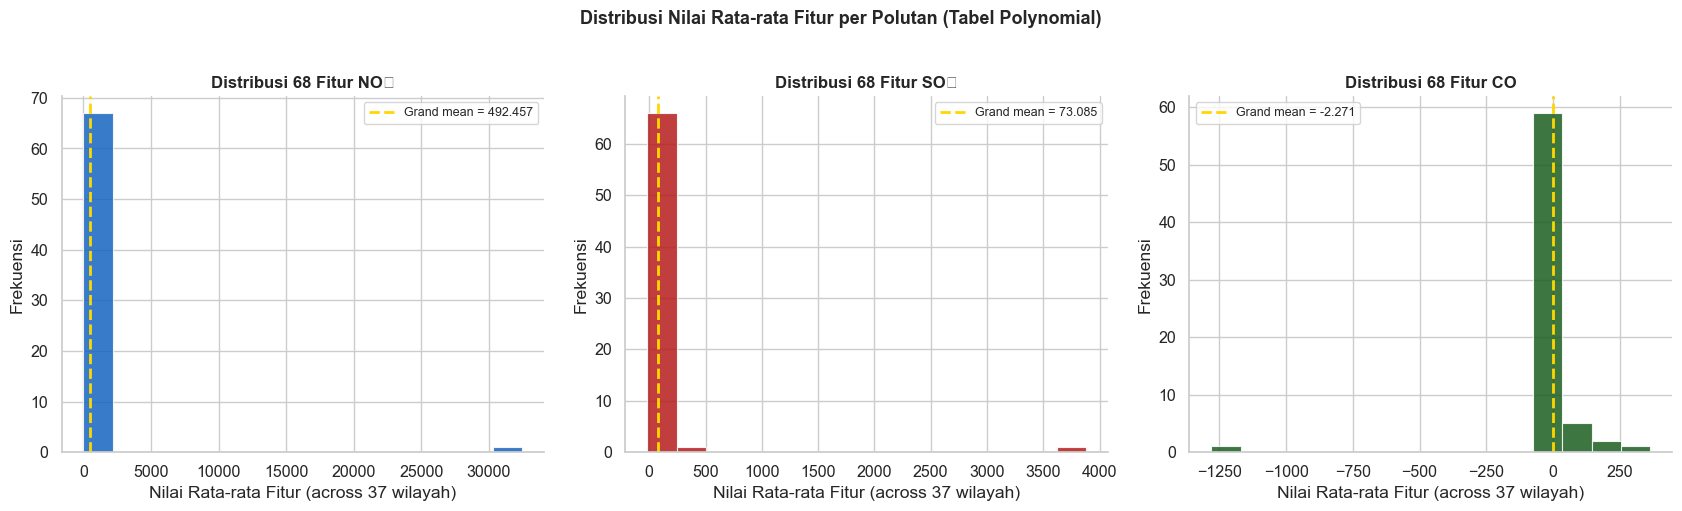

Gambar disimpan: output/01_distribusi_fitur.png


In [6]:
polutans = [('no2', '#1565C0', 'NO₂'), ('so2', '#B71C1C', 'SO₂'), ('co', '#1B5E20', 'CO')]
n_wil = X_poly.shape[0]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (prefix, color, label) in zip(axes, polutans):
    cols = [c for c in X_poly.columns if c.startswith(prefix + '_')]
    if not cols:
        ax.set_title(f'{label}: tidak ada kolom "{prefix}_*"')
        ax.axis('off')
        continue
    means = X_poly[cols].mean()

    ax.hist(means, bins=15, color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.axvline(means.mean(), color='gold', linewidth=2, linestyle='--',
               label=f'Grand mean = {means.mean():.3f}')
    ax.set_title(f'Distribusi {len(cols)} Fitur {label}', fontweight='bold', fontsize=12)
    ax.set_xlabel(f'Nilai Rata-rata Fitur (across {n_wil} wilayah)')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribusi Nilai Rata-rata Fitur per Polutan (Tabel Polynomial)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/01_distribusi_fitur.png')

## 1.7 Heatmap Korelasi Antar Fitur

Korelasi tinggi antar fitur menandakan **redundansi informasi**, yang menjadi justifikasi utama reduksi dimensi (PCA) pada tahap berikutnya.

Kita pilih **15 fitur representatif** (5 per polutan). Jika nama fitur favorit tidak ada, otomatis diganti dengan fitur dengan variasi terbesar.

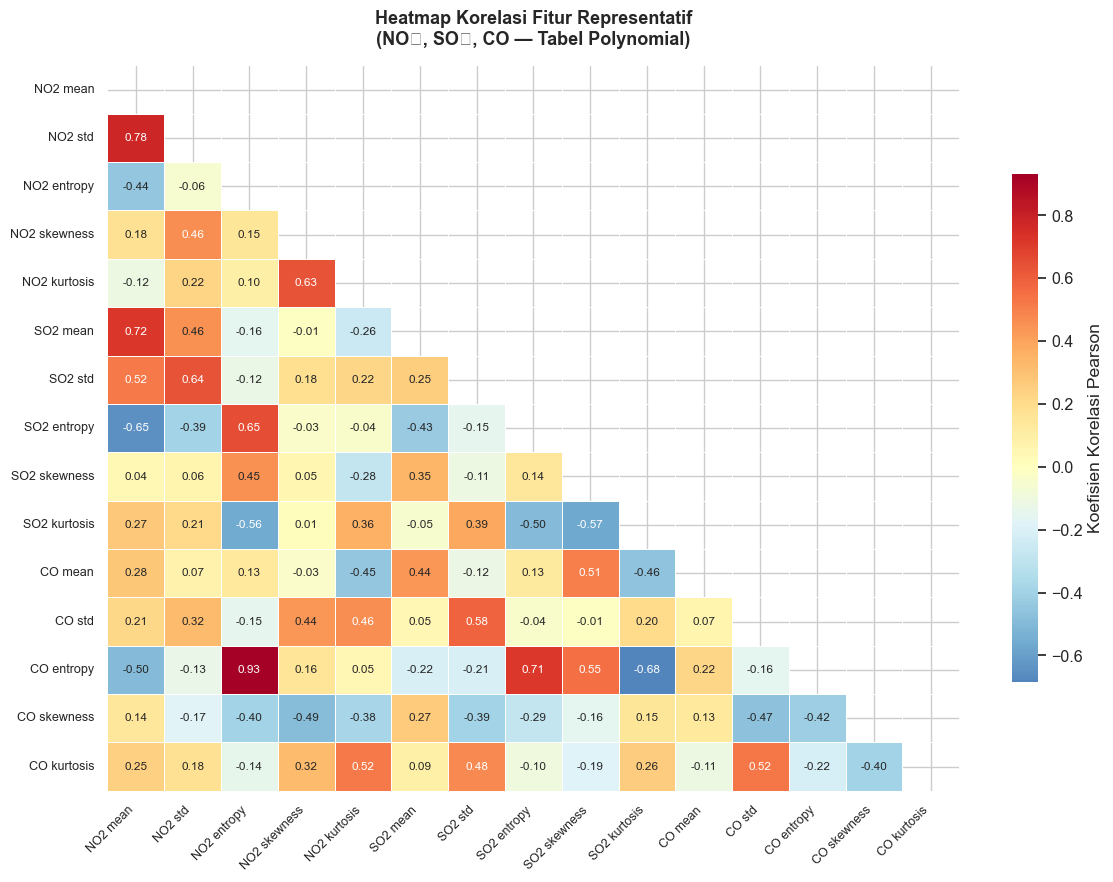

Gambar disimpan: output/02_heatmap_korelasi.png


In [7]:
candidates = ['calc_mean', 'calc_std', 'entropy', 'skewness', 'kurtosis']
feats_viz = []
for prefix in ['no2', 'so2', 'co']:
    pilih = [f'{prefix}_{c}' for c in candidates if f'{prefix}_{c}' in X_poly.columns]
    if len(pilih) < 5:   # lengkapi dengan fitur ber-variasi terbesar
        sisa = [c for c in X_poly.columns if c.startswith(prefix + '_') and c not in pilih]
        sisa = X_poly[sisa].std().sort_values(ascending=False).index.tolist()
        pilih += sisa[:5 - len(pilih)]
    feats_viz += pilih

# buang fitur konstan (std = 0) agar korelasi tidak NaN
feats_viz = [f for f in feats_viz if X_poly[f].std() > 0]
corr = X_poly[feats_viz].corr()

labels_short = [c.replace('no2_', 'NO2 ').replace('so2_', 'SO2 ')
                 .replace('co_', 'CO ').replace('calc_', '') for c in feats_viz]

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
    linewidths=0.5, annot_kws={'size': 8.5},
    xticklabels=labels_short, yticklabels=labels_short,
    cbar_kws={'shrink': 0.7, 'label': 'Koefisien Korelasi Pearson'}
)
ax.set_title('Heatmap Korelasi Fitur Representatif\n(NO₂, SO₂, CO — Tabel Polynomial)',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/02_heatmap_korelasi.png')

**Interpretasi:**
- Warna **merah tua** = korelasi positif kuat (+1), fitur bergerak searah
- Warna **biru tua** = korelasi negatif kuat (−1), fitur bergerak berlawanan
- Banyaknya sel berwarna gelap mengonfirmasi **redundansi tinggi** antar fitur dari polutan yang sama, sehingga PCA sangat dibutuhkan

## 1.8 Perbandingan Linear vs Polynomial

Kita bandingkan distribusi fitur yang sama antara dua metode interpolasi.

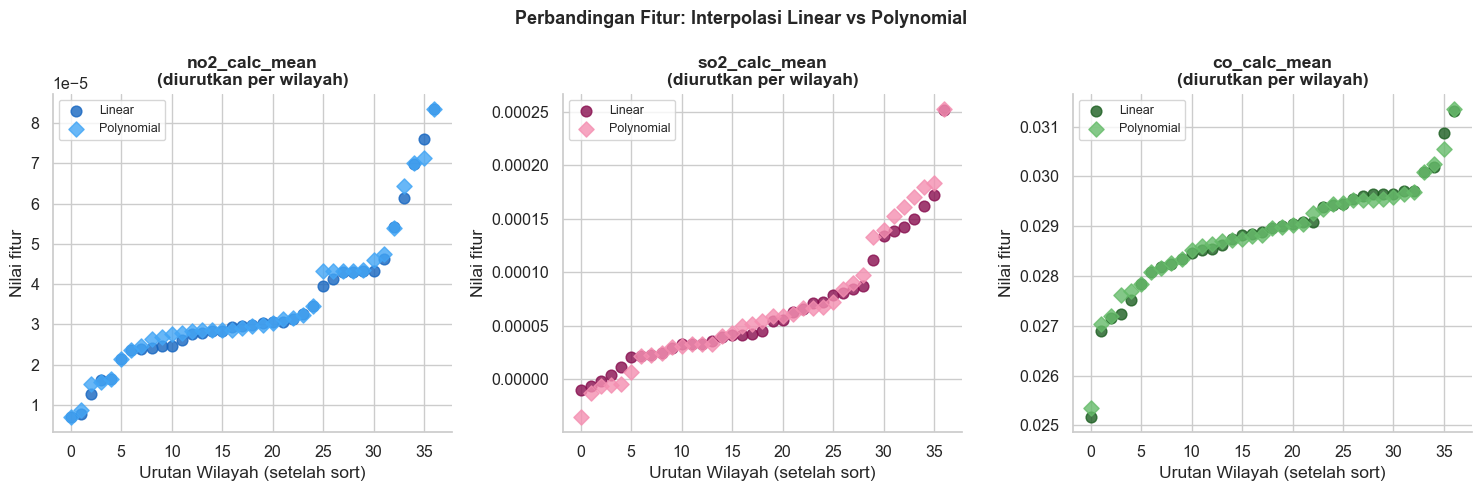

Gambar disimpan: output/03_linear_vs_poly.png


In [8]:
compare_feats = ['no2_calc_mean', 'so2_calc_mean', 'co_calc_mean']
compare_feats = [f for f in compare_feats if f in X_linear.columns and f in X_poly.columns]

# fallback: jika fitur 'calc_mean' tidak ada, pakai fitur pertama tiap polutan yang ada di kedua tabel
if not compare_feats:
    for prefix in ['no2', 'so2', 'co']:
        umum = [c for c in X_poly.columns if c.startswith(prefix + '_') and c in X_linear.columns]
        if umum:
            compare_feats.append(umum[0])

colors_lin  = ['#1565C0', '#880E4F', '#1B5E20']
colors_poly = ['#42A5F5', '#F48FB1', '#66BB6A']

fig, axes = plt.subplots(1, len(compare_feats), figsize=(5 * len(compare_feats), 5), squeeze=False)
for ax, feat, cl, cp in zip(axes[0], compare_feats, colors_lin, colors_poly):
    vals_lin  = np.sort(X_linear[feat].values)
    vals_poly = np.sort(X_poly[feat].values)

    ax.scatter(range(len(vals_lin)),  vals_lin,  color=cl, label='Linear',     s=60, alpha=0.8)
    ax.scatter(range(len(vals_poly)), vals_poly, color=cp, label='Polynomial', s=60, alpha=0.8, marker='D')
    ax.set_title(f'{feat}\n(diurutkan per wilayah)', fontweight='bold')
    ax.set_xlabel('Urutan Wilayah (setelah sort)')
    ax.set_ylabel('Nilai fitur')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Perbandingan Fitur: Interpolasi Linear vs Polynomial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_linear_vs_poly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/03_linear_vs_poly.png')

## 1.9 Simpan Data untuk Tahap Berikutnya

Data bersih disimpan dalam format **Pickle** (.pkl) agar bisa dipakai di notebook tahap berikutnya tanpa koneksi ulang ke database.

In [9]:
data_to_save = {
    'X_linear'    : X_linear,
    'X_poly'      : X_poly,
    'meta_linear' : meta_linear,
    'meta_poly'   : meta_poly,
    'META_COLS'   : META_COLS,
}

save_path = f'{OUTPUT_DIR}/tahap1_data.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f'Data disimpan ke: {os.path.abspath(save_path)}')
print(f'Ukuran file     : {os.path.getsize(save_path)/1024:.1f} KB')
print('\nRingkasan Tahap 1:')
print(f'  - Tabel dimuat     : 2 (linear + polynomial)')
print(f'  - Jumlah wilayah   : {len(meta_poly)}')
print(f'  - Jumlah fitur     : {X_poly.shape[1]} (poly), {X_linear.shape[1]} (linear)')
print(f'  - Missing values   : {int(X_poly.isnull().sum().sum())} (setelah penanganan)')
print('\n→ Lanjut ke Tahap 2: Reduksi Dimensi (PCA)')

Data disimpan ke: c:\Users\OKAN\OneDrive\Dokumen\PSD\materi\Clustering_Segmentasi\output\tahap1_data.pkl
Ukuran file     : 131.1 KB

Ringkasan Tahap 1:
  - Tabel dimuat     : 2 (linear + polynomial)
  - Jumlah wilayah   : 37
  - Jumlah fitur     : 204 (poly), 204 (linear)
  - Missing values   : 0 (setelah penanganan)

→ Lanjut ke Tahap 2: Reduksi Dimensi (PCA)
